# Live density + ERK tuning (acquire once, tune interactively)

A mix of `grid_fov_finder_erk_demo.ipynb` (a live grid scan with the ERK-KTR
gate) and `grid_density_fov_finder_tuning.ipynb` (interactive sliders).

Workflow:

1. **Set a well** and **acquire the overview once** - `GridFOVFinderAgent`
   drives the `GRID_ROWS x GRID_COLS` grid scan on the microscope, segments
   every tile, and reconstructs the centroid cloud **plus per-cell ERK CNR**.
2. **Tune interactively** - drag sliders for the density band, the clumping
   knobs, **and** the ERK gate (CNR threshold + min fraction). Each change
   re-scores the *already-acquired* cloud offline (`faro.agents.fov_density` is
   hardware-agnostic), so **nothing is re-imaged** - tuning is instant.
3. Copy the numbers you like into a live `GridFOVFinderAgent`.

The expensive part (the scan) happens once; the cheap part (scoring) is what the
sliders drive. Re-run the acquire cell to re-scan or change the well.

## 1. Microscope + channels

Two channels: nuclear marker (ch0, segmented) and the ERK-KTR reporter (ch1,
which `FE_ErkKtr` reads for CNR).

In [1]:
from faro.microscope.pertzlab.jungfrau import Jungfrau
from faro.core.data_structures import PowerChannel

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")  # PFS holds focus

imaging_channels = (
    PowerChannel(
        config="miRFP", exposure=125, group="TTL_ERK", power=95
    ),  # ch0: nuclear (segmented)
    PowerChannel(
        config="mScarlet3", exposure=150, group="TTL_ERK", power=95
    ),  # ch1: ERK-KTR reporter
)

## 2. Segmentator + ERK feature extractor

In [2]:
from faro.segmentation.cellpose_v4 import CellposeV4
from faro.feature_extraction.erk_ktr import FE_ErkKtr

segmentator = CellposeV4()
erk_fe = FE_ErkKtr("labels")  # per-cell CNR (uses imaging ch 1)

## 3. (Optional) napari viewer for live focus

In [ ]:
from napari_micromanager import MainWindow
import napari

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer, mmcore=mic.mmc)
viewer.window.add_dock_widget(mm_wdg)

## 4. Set a well + acquire the overview (run once)

This drives the stage: a `GRID_ROWS x GRID_COLS` grid scan on `WELL`, segmenting
each tile and reconstructing the centroid cloud + per-cell CNR. We attach a
**permissive** CNR condition here only so the scan computes the per-cell CNR
cloud - the finder's own `min_cells` / `clump` / threshold values in *this* cell
don't matter, because the real gate is tuned with the sliders below.

`store_tiles=True` keeps the tiles so the tuning plot can show the stitched
overview as a background. Re-run this cell to re-scan or change `WELL`.

In [3]:
import numpy as np
from faro.agents import GridFOVFinderAgent, FOVCondition

WELL = "C7"  # <-- set the well to scan
GRID_ROWS, GRID_COLS = 5, 5
GRID_OVERLAP = 0.05
PIXEL_SIZE_UM = 0.65
FLIP_X, FLIP_Y = False, True  # camera->stage flips (~180 deg plate rotation)

finder = GridFOVFinderAgent(
    microscope=mic,
    well_plate_plan="./calib_plate_96.json",
    wells=[WELL],
    fovs_per_well=3,
    grid_rows=GRID_ROWS,
    grid_cols=GRID_COLS,
    grid_overlap=GRID_OVERLAP,
    # permissive during acquire -- the real band/gate is tuned interactively below
    min_cells=1,
    max_cells=None,
    clump_distance_um=15.0,
    max_clumped_fraction=1.0,
    recenter=True,
    feature_extractor=erk_fe,
    fov_conditions=[
        FOVCondition("cnr", "below", 1e9, min_fraction=0.0)
    ],  # permissive: just compute CNR
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,
    z=None,
    flip_x=FLIP_X,
    flip_y=FLIP_Y,
    pixel_size_um=PIXEL_SIZE_UM,
    fov_size_um=None,
    store_tiles=True,  # keep tiles for the overview montage background
    verbose=False,
)

finder.run()  # 25-tile grid scan on WELL (drives the stage)
lr = finder.last_run
cloud = lr["clouds_by_well"][WELL]  # (N, 2) centroids, um
cnr = lr["feats_by_well"][WELL]["cnr"]  # (N,) per-cell CNR, aligned to cloud
fov_w, fov_h = lr["fov_size_um"]
print(
    f"acquired {WELL}: {len(cloud)} cells; FOV window {fov_w:.0f}x{fov_h:.0f} um; "
    f"median CNR {float(np.nanmedian(cnr)):.2f}, "
    f"ready frac (CNR<1.0) {float(np.nanmean(cnr < 1.0)):.2f}"
)

[GridFOVFinderAgent] Phase 0 — selected FOVs:
    C7_0000: 137 cells, clumped=0.34, med_nn=17.8µm
    C7_0001: 14 cells, clumped=0.00, med_nn=74.1µm
    C7_0002: 3 cells, clumped=0.00, med_nn=220.9µm
acquired C7: 621 cells; FOV window 666x666 um; median CNR 0.98, ready frac (CNR<1.0) 0.56


## 5. Tune interactively (density / clumping / ERK gate)

Each slider change re-scores the stored cloud - **no re-imaging**. The plot shows
the stitched overview (grey), cells coloured by CNR (blue = ERK-ready), the
selected FOVs (green boxes), and - when the gate is on - windows that pass
density but **fail the ERK gate** (orange). Sliders:

- **density band**: `min_cells`, `max_cells` (0 = no upper limit)
- **clumping**: `clump_distance_um`, `max_clumped_fraction`
- **spread band**: `min_nn_um`, `max_nn_um` (0 = off)
- **ERK gate**: `apply_erk_gate`, `cnr_threshold`, `cnr_min_fraction`
- `n_select`, `recenter`

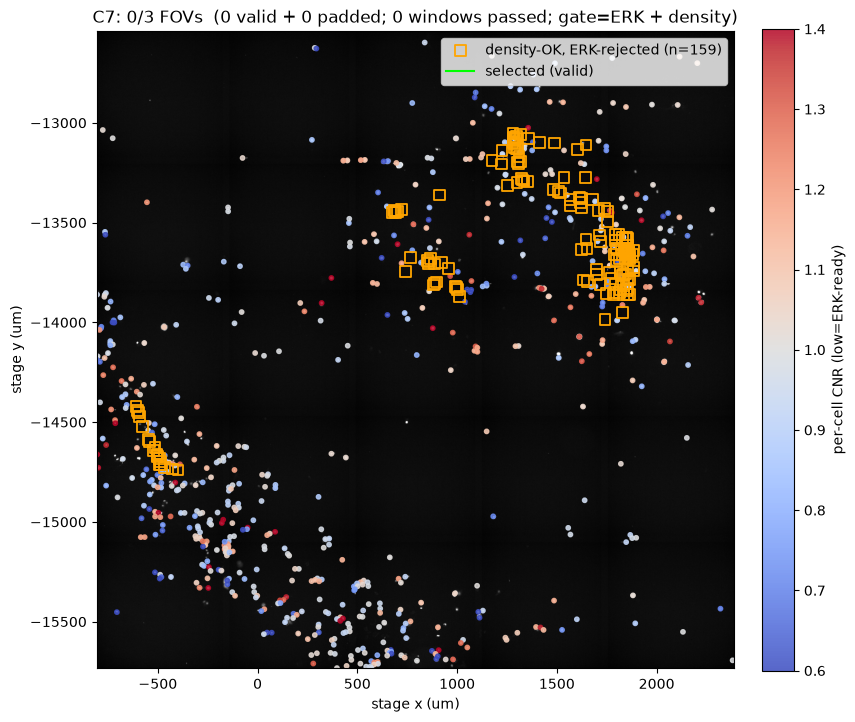

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from faro.agents.fov_density import (
    FovDensityScorer,
    find_fov_windows,
    build_stage_montage,
)
from faro.agents import FOVCondition

# Stitch the acquired tiles into a stage-coordinate montage once (background).
MONTAGE, EXTENT = None, None
_tims = lr.get("tile_images_by_well", {}).get(WELL)
if _tims:
    _tiles = lr["tiles_by_well"][WELL]
    _keep = [
        (np.array([t.x, t.y]), im) for t, im in zip(_tiles, _tims) if im is not None
    ]
    if _keep:
        MONTAGE, EXTENT = build_stage_montage(
            np.array([c for c, _ in _keep]),
            [im for _, im in _keep],
            lr["pixel_size_um"],
            flip_x=lr["flip_x"],
            flip_y=lr["flip_y"],
        )


def run_and_plot(
    min_cells=35,
    max_cells=100,
    clump_distance_um=15.0,
    max_clumped_fraction=0.2,
    min_nn_um=0.0,
    max_nn_um=0.0,
    apply_erk_gate=True,
    cnr_threshold=1.0,
    cnr_min_fraction=0.7,
    n_select=3,
    recenter=True,
    fill_invalid=False,
):
    conds = (
        [FOVCondition("cnr", "below", cnr_threshold, min_fraction=cnr_min_fraction)]
        if apply_erk_gate
        else []
    )
    scorer = FovDensityScorer(
        fov_w_um=fov_w,
        fov_h_um=fov_h,
        min_cells=min_cells,
        max_cells=(None if max_cells <= 0 else max_cells),
        clump_distance_um=clump_distance_um,
        max_clumped_fraction=max_clumped_fraction,
        min_nn_um=(None if min_nn_um <= 0 else min_nn_um),
        max_nn_um=(None if max_nn_um <= 0 else max_nn_um),
        fov_conditions=conds,
    )
    df_all, df_sel = find_fov_windows(
        cloud,
        scorer,
        n_select=n_select,
        recenter=recenter,
        feat=({"cnr": cnr} if apply_erk_gate else None),
        fill_invalid=fill_invalid,
    )

    fig, ax = plt.subplots(figsize=(9, 9))
    if MONTAGE is not None:
        ax.imshow(
            MONTAGE,
            origin="lower",
            extent=EXTENT,
            cmap="gray",
            vmin=np.percentile(MONTAGE, 1),
            vmax=np.percentile(MONTAGE, 99.5),
        )
    sc = ax.scatter(
        cloud[:, 0],
        cloud[:, 1],
        c=cnr,
        cmap="coolwarm",
        vmin=0.6,
        vmax=1.4,
        s=10,
        alpha=0.85,
    )
    fig.colorbar(
        sc, ax=ax, fraction=0.046, pad=0.04, label="per-cell CNR (low=ERK-ready)"
    )

    if apply_erk_gate and len(df_all):
        rej = df_all[df_all["reason"] == "condition_failed"]
        if len(rej):
            ax.scatter(
                rej["x"],
                rej["y"],
                marker="s",
                s=60,
                facecolors="none",
                edgecolors="orange",
                linewidths=1.3,
                label=f"density-OK, ERK-rejected (n={len(rej)})",
            )
    # Selected FOVs: valid (green solid) vs padded fallback fills (red dashed,
    # labelled with the reason they were rejected by the band/gate).
    sel_valid = df_sel[df_sel["valid"]] if len(df_sel) else df_sel
    sel_pad = df_sel[~df_sel["valid"]] if len(df_sel) else df_sel
    for _, r in sel_valid.iterrows():
        ax.add_patch(
            Rectangle(
                (r["x"] - fov_w / 2, r["y"] - fov_h / 2),
                fov_w,
                fov_h,
                fill=False,
                edgecolor="lime",
                linewidth=2.5,
            )
        )
        ax.plot(r["x"], r["y"], "x", color="lime", markersize=11, markeredgewidth=2.5)
    for _, r in sel_pad.iterrows():
        ax.add_patch(
            Rectangle(
                (r["x"] - fov_w / 2, r["y"] - fov_h / 2),
                fov_w,
                fov_h,
                fill=False,
                edgecolor="red",
                linewidth=2.5,
                linestyle="--",
            )
        )
        ax.plot(r["x"], r["y"], "+", color="red", markersize=13, markeredgewidth=2.5)
        ax.annotate(
            f"padded: {r['reason']}",
            (r["x"], r["y"]),
            color="red",
            fontsize=8,
            ha="center",
            va="bottom",
            xytext=(0, 6),
            textcoords="offset points",
        )
    ax.plot([], [], color="lime", label="selected (valid)")
    if len(sel_pad):
        ax.plot(
            [], [], color="red", linestyle="--", label="padded fill (below threshold)"
        )

    n_valid = int(df_all["valid"].sum()) if len(df_all) else 0
    gate = "ERK + density" if apply_erk_gate else "density only"
    ax.set_title(
        f"{WELL}: {len(df_sel)}/{n_select} FOVs  "
        f"({len(sel_valid)} valid + {len(sel_pad)} padded; "
        f"{n_valid} windows passed; gate={gate})"
    )
    ax.set_xlabel("stage x (um)")
    ax.set_ylabel("stage y (um)")
    ax.set_aspect("equal")
    ax.legend(loc="upper right")
    plt.show()

    if len(df_sel):
        disp = df_sel.copy()
        disp["kind"] = np.where(disp["valid"].to_numpy(), "valid", "PADDED")
        cols = [
            "kind",
            "x",
            "y",
            "n_cells",
            "clumped_fraction",
            "median_nn_um",
            "cond_cnr_below_frac",
            "reason",
            "score",
        ]
        print(
            disp[[c for c in cols if c in disp.columns]].round(2).to_string(index=False)
        )
    return df_all, df_sel


_ = run_and_plot()

In [5]:
try:
    from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

    interact(
        run_and_plot,
        min_cells=IntSlider(value=35, min=1, max=200, step=1),
        max_cells=IntSlider(value=100, min=0, max=400, step=5),  # 0 = no upper limit
        clump_distance_um=FloatSlider(value=15.0, min=2.0, max=60.0, step=1.0),
        max_clumped_fraction=FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05),
        min_nn_um=FloatSlider(value=0.0, min=0.0, max=60.0, step=1.0),  # 0 = off
        max_nn_um=FloatSlider(value=0.0, min=0.0, max=200.0, step=5.0),  # 0 = off
        apply_erk_gate=Checkbox(value=True),
        cnr_threshold=FloatSlider(value=1.0, min=0.5, max=2.0, step=0.05),
        cnr_min_fraction=FloatSlider(value=0.7, min=0.0, max=1.0, step=0.05),
        n_select=IntSlider(value=3, min=1, max=8, step=1),
        recenter=Checkbox(value=True),
    )
except ImportError:
    print("ipywidgets not available - call run_and_plot(...) with kwargs directly.")
    _ = run_and_plot(min_cells=35, clump_distance_um=10.0, max_clumped_fraction=0.2)

interactive(children=(IntSlider(value=35, description='min_cells', max=200, min=1), IntSlider(value=100, descr…

## 6. What padding does - which FOVs get used (strict_count)

Section 5 used `fill_invalid=False`, so a strict band/gate returns **fewer** than
`n_select` FOVs. The live `GridFOVFinderAgent` instead defaults to
`strict_count=True`, which **pads** up to `n_select` so downstream agents (e.g.
`OscillationBO`, which splits FOVs into equal groups) always get a fixed count.

**Which FOVs get used as padding:**

1. **valid windows first**, spread as far apart as possible (farthest-point);
2. then, if still short, **top up from the rejected windows** - picking the
   *best-scoring* (densest, least-clumped) leftover, **regardless of why it was
   rejected** (`too_clumped`, `below_min_cells`, `above_max_cells`, or
   `condition_failed` = ERK-not-ready);
3. **non-overlap is always enforced**, even for fills.

So padding trades quality for count: a padded FOV can be clumped or not
ERK-ready (it carries its reject `reason`). Below, padding is **on**
(`fill_invalid=True`) with a deliberately strict band so valid windows run out -
the fills appear as **red dashed** boxes labelled with their reason, while real
picks stay **green**. Tighten/loosen the sliders to watch the valid/padded split
change. Set `strict_count=False` on the live finder to keep padding OFF and
return fewer FOVs instead.

In [6]:
try:
    from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

    interact(
        run_and_plot,
        min_cells=IntSlider(value=80, min=1, max=200, step=1),  # strict on purpose
        max_cells=IntSlider(value=100, min=0, max=400, step=5),
        clump_distance_um=FloatSlider(value=15.0, min=2.0, max=60.0, step=1.0),
        max_clumped_fraction=FloatSlider(
            value=0.1, min=0.0, max=1.0, step=0.05
        ),  # strict
        min_nn_um=FloatSlider(value=0.0, min=0.0, max=60.0, step=1.0),
        max_nn_um=FloatSlider(value=0.0, min=0.0, max=200.0, step=5.0),
        apply_erk_gate=Checkbox(value=True),
        cnr_threshold=FloatSlider(value=1.0, min=0.5, max=2.0, step=0.05),
        cnr_min_fraction=FloatSlider(value=0.9, min=0.0, max=1.0, step=0.05),  # strict
        n_select=IntSlider(value=3, min=1, max=8, step=1),
        recenter=Checkbox(value=True),
        fill_invalid=Checkbox(value=True),  # <-- padding ON (strict_count behaviour)
    )
except ImportError:
    print(
        "ipywidgets not available - call run_and_plot(..., fill_invalid=True) directly."
    )
    _ = run_and_plot(
        min_cells=80, max_clumped_fraction=0.1, cnr_min_fraction=0.9, fill_invalid=True
    )

interactive(children=(IntSlider(value=80, description='min_cells', max=200, min=1), IntSlider(value=100, descr…

## 7. Apply the tuned numbers to the live finder

Once the sliders give you a selection you like, copy the same numbers into a
`GridFOVFinderAgent` (or the `finder=` you hand to `run_well_patterns_async` in
an experiment notebook). The agent runs this exact scorer on the live grid scan:

```python
from faro.agents import GridFOVFinderAgent, FOVCondition
from faro.feature_extraction.erk_ktr import FE_ErkKtr

finder = GridFOVFinderAgent(
    microscope=mic,
    well_plate_plan="./calib_plate_96.json",
    wells=["B2", "B3", "B4"],
    fovs_per_well=3,
    grid_rows=5, grid_cols=5, grid_overlap=0.05,
    # density band you tuned above:
    min_cells=35, max_cells=100,
    clump_distance_um=15.0, max_clumped_fraction=0.2,
    # ERK gate you tuned above (drop these two for density-only):
    feature_extractor=FE_ErkKtr("labels"),
    fov_conditions=[FOVCondition("cnr", "below", 1.0, min_fraction=0.7)],
    imaging_channels=imaging_channels,
    segmentator=segmentator, seg_channel_index=0,
    z=None, flip_x=False, flip_y=True,
    pixel_size_um=0.65,
)
positions = finder.run()
```

See `grid_fov_finder_erk_demo.ipynb` for the full live ERK demo and
`grid_density_fov_finder_tuning.ipynb` for the offline (zarr) tuning variant.